1. (a)Calculate the output of a simple neuron using the following activation functions

 Unit Step
 Sign (Signum)
 Linear
 Piece-wise linear
 Logistic(Sigmoid)
 Hyperbolic Tangent

Simple neuron values may range from (5 to 10) as discussed in the class. Use different range of
values and explore. Display appropriate graphs

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Neuron parameters

In [ ]:
w = 2
b = -10

Generate random input values between 5 and 10

In [ ]:
x_values = np.random.uniform(5, 10, 100)
def unit_step(x):
    return np.heaviside(x, 1)

def signum(x):
    return np.sign(x)

def linear(x):
    return x

def piecewise_linear(x):
    return np.piecewise(x, [x < 0, x >= 0], [0, lambda x: x])

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def hyperbolic_tangent(x):
    return np.tanh(x)

Calculating neuron output for each activation function

In [ ]:
y_unit_step = unit_step(w * x_values + b)
y_signum = signum(w * x_values + b)
y_linear = linear(w * x_values + b)
y_piecewise_linear = piecewise_linear(w * x_values + b)
y_sigmoid = sigmoid(w * x_values + b)
y_tanh = hyperbolic_tangent(w * x_values + b)

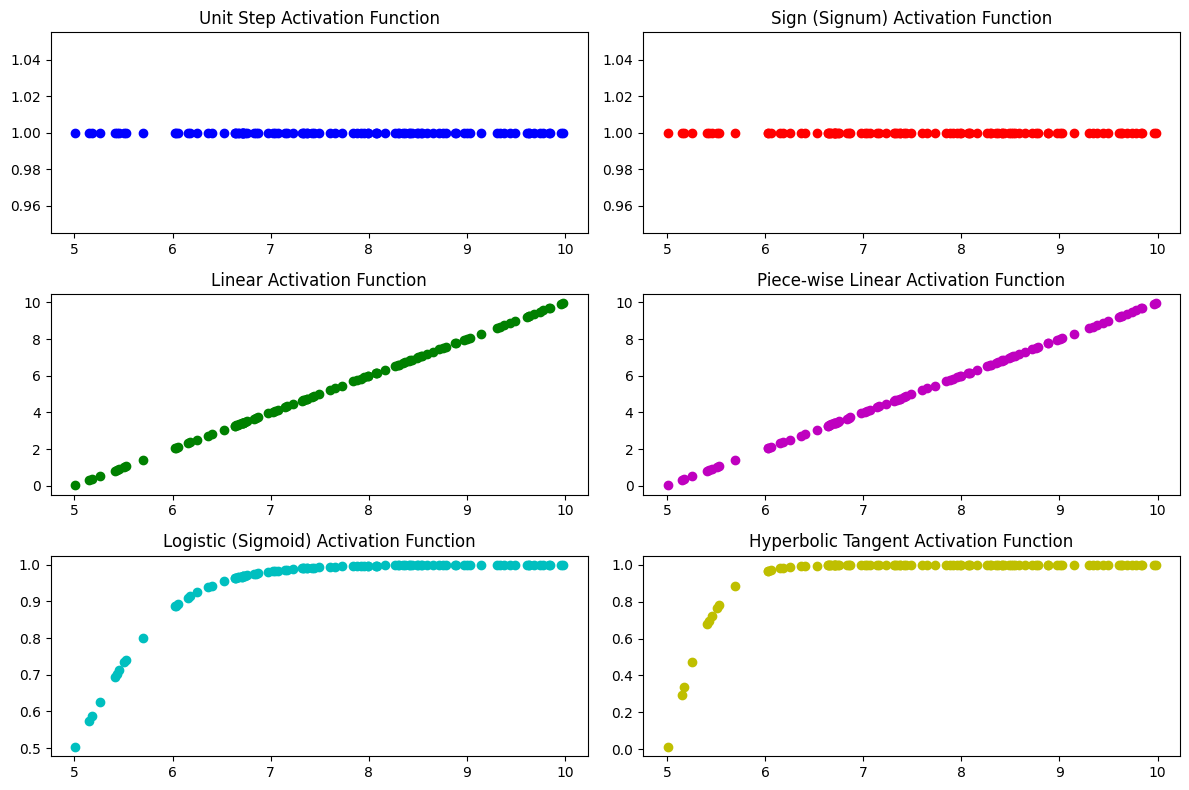

In [ ]:
plt.figure(figsize=(12, 8))

plt.subplot(3, 2, 1)
plt.plot(x_values, y_unit_step, 'bo')
plt.title('Unit Step Activation Function')

plt.subplot(3, 2, 2)
plt.plot(x_values, y_signum, 'ro')
plt.title('Sign (Signum) Activation Function')

plt.subplot(3, 2, 3)
plt.plot(x_values, y_linear, 'go')
plt.title('Linear Activation Function')

plt.subplot(3, 2, 4)
plt.plot(x_values, y_piecewise_linear, 'mo')
plt.title('Piece-wise Linear Activation Function')

plt.subplot(3, 2, 5)
plt.plot(x_values, y_sigmoid, 'co')
plt.title('Logistic (Sigmoid) Activation Function')

plt.subplot(3, 2, 6)
plt.plot(x_values, y_tanh, 'yo')
plt.title('Hyperbolic Tangent Activation Function')

plt.tight_layout()
plt.show()

(b) Import iris dataset, use any one attribute value as input to the simple neuron apply all the
activation function mentioned in Q1 (a) display the graphs and Give your observation.

In [ ]:
from sklearn.datasets import load_iris

using Sepal length attribute as input

In [ ]:
iris = load_iris()
sepal_length = iris.data[:, 0]

In [ ]:
y_unit_step = unit_step(w * sepal_length + b)
y_signum = signum(w * sepal_length + b)
y_linear = linear(w * sepal_length + b)
y_piecewise_linear = piecewise_linear(w * sepal_length + b)
y_sigmoid = sigmoid(w * sepal_length + b)
y_tanh = hyperbolic_tangent(w * sepal_length + b)

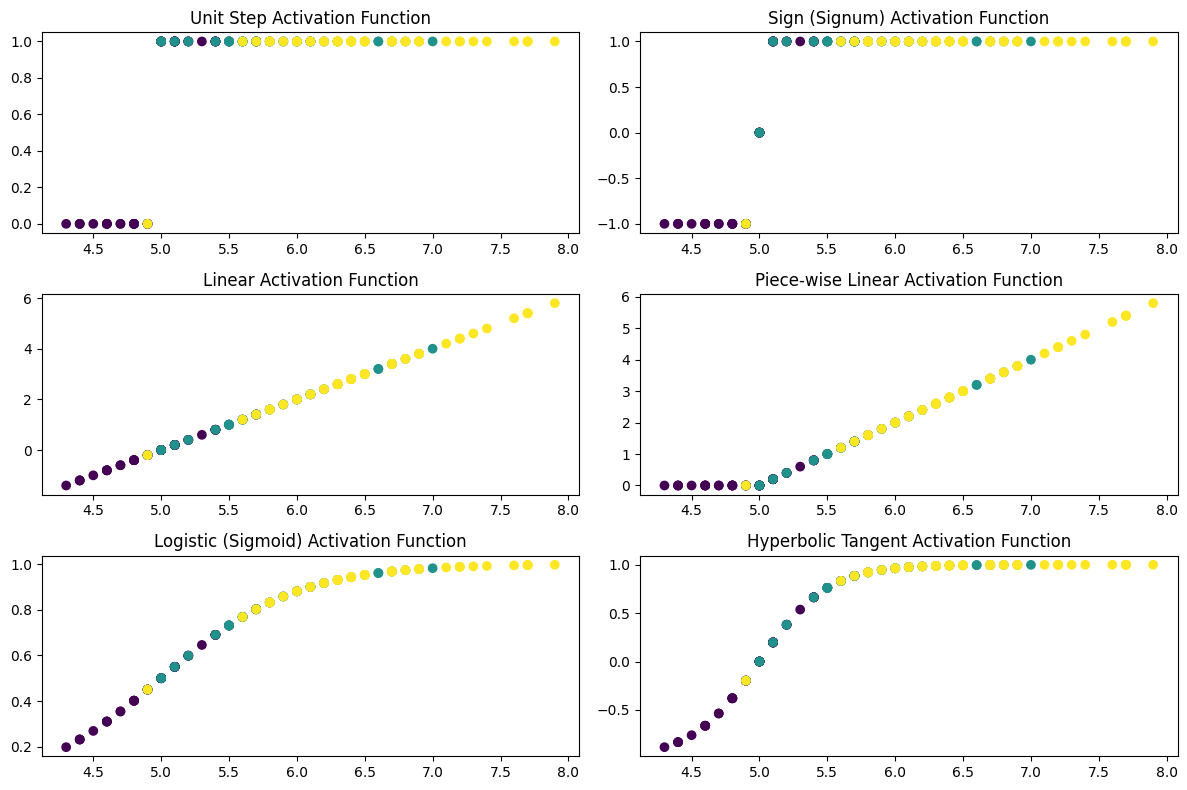

In [ ]:
plt.figure(figsize=(12, 8))

plt.subplot(3, 2, 1)
plt.scatter(sepal_length, y_unit_step, c=iris.target)
plt.title('Unit Step Activation Function')

plt.subplot(3, 2, 2)
plt.scatter(sepal_length, y_signum, c=iris.target)
plt.title('Sign (Signum) Activation Function')

plt.subplot(3, 2, 3)
plt.scatter(sepal_length, y_linear, c=iris.target)
plt.title('Linear Activation Function')

plt.subplot(3, 2, 4)
plt.scatter(sepal_length, y_piecewise_linear, c=iris.target)
plt.title('Piece-wise Linear Activation Function')

plt.subplot(3, 2, 5)
plt.scatter(sepal_length, y_sigmoid, c=iris.target)
plt.title('Logistic (Sigmoid) Activation Function')

plt.subplot(3, 2, 6)
plt.scatter(sepal_length, y_tanh, c=iris.target)
plt.title('Hyperbolic Tangent Activation Function')

plt.tight_layout()
plt.show()

2. Explore MLP for the same dataset

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

In [ ]:
X = iris.data
y = iris.target

Splitting data into trainig and test set

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Creating and training mlp classifier

In [ ]:
mlp_classifier = MLPClassifier(hidden_layer_sizes=(10, 5), max_iter=1000, random_state=42)
mlp_classifier.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(10, 5), max_iter=1000, random_state=42)

Predictions on the test set

In [ ]:
y_pred = mlp_classifier.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 96.67%
Confusion Matrix:
[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]


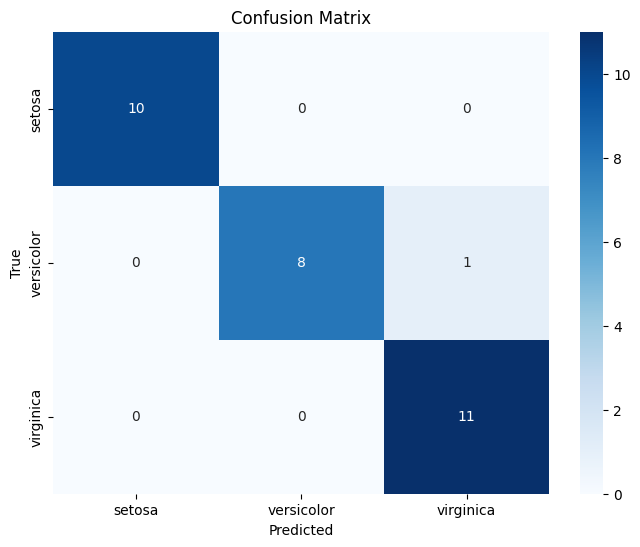

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

3. Create a perceptron to demonstrate the following
a. AND operation
b. OR operation
c. XOR operation
Use two input neurons and one output neuron, Assign weights as follows and compute the
value
W1=0.5, w2=0.243, w0 = 0.2
Display the error for each function

In [ ]:
def perceptron(x1, x2, w1, w2, w0):
    weighted_sum = w1 * x1 + w2 * x2 + w0
    output = 1 if weighted_sum >= 0 else 0
    return output

def compute_error(y_actual, y_expected):
    return abs(y_actual - y_expected)

w1 = 0.5
w2 = 0.243
w0 = 0.2

x1_and = [0, 0, 1, 1]
x2_and = [0, 1, 0, 1]
y_expected_and = [0, 0, 0, 1]

print("AND operation:")
for i in range(4):
    y_actual_and = perceptron(x1_and[i], x2_and[i], w1, w2, w0)
    error_and = compute_error(y_actual_and, y_expected_and[i])
    print(f"Input: ({x1_and[i]}, {x2_and[i]}), Actual: {y_actual_and}, Expected: {y_expected_and[i]}, Error: {error_and}")

x1_or = [0, 0, 1, 1]
x2_or = [0, 1, 0, 1]
y_expected_or = [0, 1, 1, 1]

print("\nOR operation:")
for i in range(4):
    y_actual_or = perceptron(x1_or[i], x2_or[i], w1, w2, w0)
    error_or = compute_error(y_actual_or, y_expected_or[i])
    print(f"Input: ({x1_or[i]}, {x2_or[i]}), Actual: {y_actual_or}, Expected: {y_expected_or[i]}, Error: {error_or}")

x1_xor = [0, 0, 1, 1]
x2_xor = [0, 1, 0, 1]
y_expected_xor = [0, 1, 1, 0]

print("\nXOR operation:")
for i in range(4):
    y_actual_xor = perceptron(x1_xor[i], x2_xor[i], w1, w2, w0)
    error_xor = compute_error(y_actual_xor, y_expected_xor[i])
    print(f"Input: ({x1_xor[i]}, {x2_xor[i]}), Actual: {y_actual_xor}, Expected: {y_expected_xor[i]}, Error: {error_xor}")


AND operation:
Input: (0, 0), Actual: 1, Expected: 0, Error: 1
Input: (0, 1), Actual: 1, Expected: 0, Error: 1
Input: (1, 0), Actual: 1, Expected: 0, Error: 1
Input: (1, 1), Actual: 1, Expected: 1, Error: 0

OR operation:
Input: (0, 0), Actual: 1, Expected: 0, Error: 1
Input: (0, 1), Actual: 1, Expected: 1, Error: 0
Input: (1, 0), Actual: 1, Expected: 1, Error: 0
Input: (1, 1), Actual: 1, Expected: 1, Error: 0

XOR operation:
Input: (0, 0), Actual: 1, Expected: 0, Error: 1
Input: (0, 1), Actual: 1, Expected: 1, Error: 0
Input: (1, 0), Actual: 1, Expected: 1, Error: 0
Input: (1, 1), Actual: 1, Expected: 0, Error: 1
